# ZH2 
A feladatokat **ebbe a notebookba** oldd meg! Nem kell új file-t létrehozni!
Az alábbi kódcella futtatásával a ZH megoldásához szükséges összes python csomag betöltődik a környezetbe.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pickle
import matplotlib as mpl

---

# 1. Feladat

A `data1` állományban találod egy CCD egység jelét. 
A file-ban két oszlop van. Az első oszlop tartalmazza a CCD-t alkotó pixelek pozíciójának koordinátáját mm-ben, a második oszlop pedig az adott pozícióban észlelt egy adott háttérhez viszonyított relatív intenzitást beütés/másodpercben. 
- Olvasd be az adatokat! <span style="color:red">(1p)</span>
- Illessz az adatokra $$ I(x)=\frac{\alpha}{(x^2+\beta^2-2x\beta)(x-2x\gamma+\gamma^2)+\delta^2} $$ alakú függvényt! <span style="color:red">(1p)</span>
- Készíts egy ábrát, amin a mért adatokat és az illesztett függvényt ábrázolod! <span style="color:red">(1p)</span>
- Írd le az illesztett $\alpha$, $\beta$, $\gamma$ és $\delta$ paraméterek értékét és a paraméterek illesztési hibáját! <span style="color:red">(1p)</span>
- A saját szavaiddal fogalmazd meg, hogy az ábra alapján melyik pozíció(k) körül volt a legnagyobb az intenzitás!  <span style="color:red">(1p)</span>

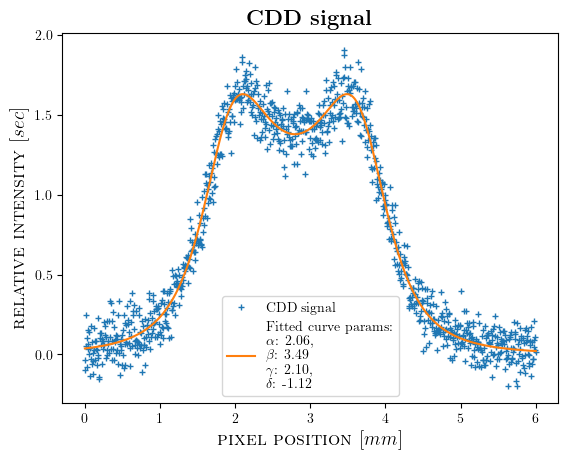

The standard deviation of the parameters are:
   alpha = 0.04366
   beta  = 0.00653
   gamma = 0.00653
   delta = 0.01356


In [100]:
file = "data1"


def SetTex():
    """
    Sets TeX fonts.
    """

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = 'cm'


def read_data1(filename):
    
    data = []
    
    with open(filename) as file:
        lines = file.readlines()
        for line in lines:
            split = line.split(' ')
            
            data.append([float(split[0]), float(split[1])])
            
    return np.array(data)

def f(x, alpha, beta, gamma, delta):
    poly_1 = x**2 + beta**2 - 2*x*beta
    poly_2 = x**2 - 2*x*gamma + gamma**2
    
    return alpha / (poly_1 * poly_2 + delta**2)
    
def plot(data):
    
    SetTex()
    
    plt.plot(data[:, 0], data[:, 1], "+", markersize=5, label="CDD signal")
    
    xdata = np.linspace(np.min(data[:, 0]), np.max(data[:, 0]), 300)
    p0 = [0.05, 2, 1.5, -4]
    res, res_cov = curve_fit(f, data[:, 0], data[:, 1], p0=p0)
    
    fit = f(xdata, *res)

    plt.plot(xdata, fit, label=fr"Fitted curve params: {"\n"}$\alpha$: {res[0]:.2f}, {"\n"}$\beta$: {res[1]:.2f} {"\n"}$\gamma$: {res[2]:.2f}, {"\n"}$\delta$: {res[3]:.2f}")
    
    # ------------------------------------------
    
    plt.title(r"\textbf{CDD signal}", size=16)
    plt.xlabel(r"\textsc{pixel position} [$mm$]", size=14)
    plt.ylabel(r"\textsc{relative intensity} [$sec$]", size=14)
    
    plt.legend()
    plt.show()
    
    perr = np.sqrt(np.diag(res_cov))
    print(f"The standard deviation of the parameters are:")
    print(f"   alpha = {perr[0]:.5f}")
    print(f"   beta  = {perr[1]:.5f}")
    print(f"   gamma = {perr[2]:.5f}")
    print(f"   delta = {perr[3]:.5f}")
    
    
dat = read_data1(file)

plot(dat)

### Értelmezés

Az ábrából látszik hogy kettő "dombocska" van az adatban, körülbelül 2 és 4 $mm$-nél.

---

# 2. Feladat

A `data2.npy` állomány egy `numpy` bináris formátumú file, mely a Csernobili atomkatasztrófa során tevékenykedő négy különböző likvidátor zsebében meglapuló doziméter által mért, egy referencia értékhez viszonyított (3.6 R-hez), ionizáló sugárzásnak való kitettség adatait tartalmazza R egységben az idő függvényében. Az idő egy adott referencia nap deléhez képest nap mértékegységben volt feljegyezve. A file-ban egy 8 soros és 314 oszlopos `array` típusú változóba vannak elmentve az adatok. **Figyelem:** A doziméterek mérési bejegyzései nem ugyanabban az időpontban készültek és egy rendszerhiba miatt nincsenek időrendbe rendezve! A `array` páratlan sorai tartalmazzák a négy doziméter mérési időpontjait, a páros sorokban pedig a mért értékek találhatóak, tehát az első sorban az első doziméter mérési időpontjai a második sorban pedig az első doziméter által mért értékek találhatóak. Anatolij Sztyepanovics Gyatlov szerint ha nyolcad fokú polinomokat illesztenénk az adatsorra az nem lenne rossz.

- Olvasd be az adatokat a `numpy` bináris file-ok beolvasására szolgáló rutinjával! <span style="color:red">(1p)</span>
- Illessz mind a négy adatsorra egy nyolcadfokú polinomot! **Figyelem:** minden illesztés során kilenc paramétert kell meghatároznod! <span style="color:red">(1p)</span>
- Az illesztett paraméterek értékét és a paraméterek illesztési hibáját tüntesd fel a notebookban! <span style="color:red">(1p)</span>
- Készíts négy ábrát a mért adatokról és az illesztett függvényekről! <span style="color:red">(1p)</span> 
- A saját szavaiddal fogalmazd meg, a négy doziméter mindegyikére, hogy az illesztett együtthatók közül melyiknek volt a legnagyobb az abszolút értéke! <span style="color:red">(1p)</span>

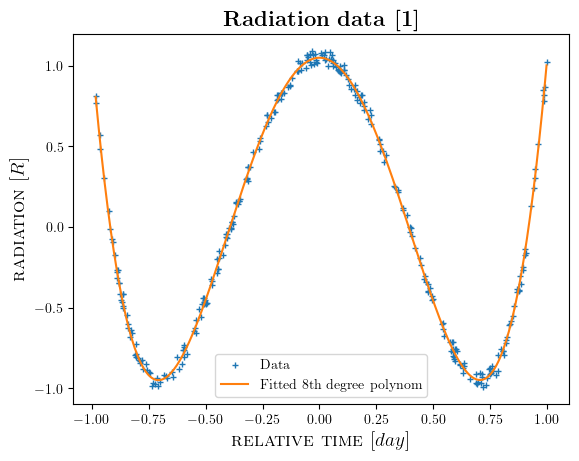

Results of measurement 1:
  a: 0.28670
  b: -0.20487
  c: -0.62609
  d: 0.27586
  e: 8.44618
  f: -0.08894
  g: -8.10069
  h: 0.00185
  j: 1.04984
The standard deviation of the measurement
  a: 0.36053
  b: 0.17829
  c: 0.67416
  d: 0.29071
  e: 0.39988
  f: 0.14141
  g: 0.07962
  h: 0.01989
  j: 0.00372


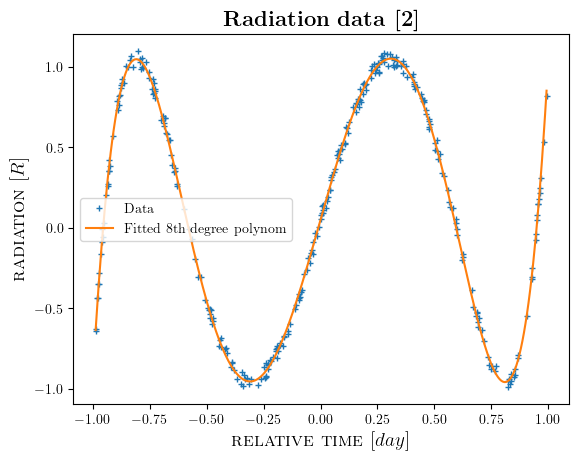

Results of measurement 2:
  a: 0.10279
  b: -0.06222
  c: -0.16359
  d: 16.14915
  e: 0.08355
  f: -20.10408
  g: -0.02130
  h: 5.01768
  j: 0.05021
The standard deviation of the measurement
  a: 0.38040
  b: 0.19216
  c: 0.70111
  d: 0.30831
  e: 0.40993
  f: 0.14392
  g: 0.08155
  h: 0.01897
  j: 0.00381


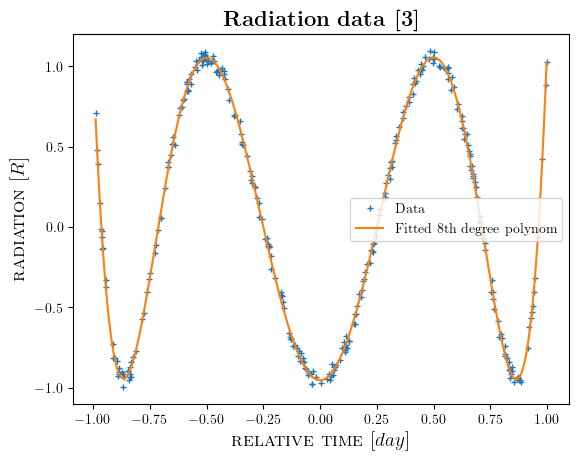

Results of measurement 3:
  a: -0.29315
  b: 0.25992
  c: 32.62790
  d: -0.35299
  e: -48.41668
  f: 0.13175
  g: 18.09357
  h: -0.01280
  j: -0.95248
The standard deviation of the measurement
  a: 0.35950
  b: 0.17335
  c: 0.67824
  d: 0.28128
  e: 0.40882
  f: 0.13571
  g: 0.08419
  h: 0.01914
  j: 0.00419


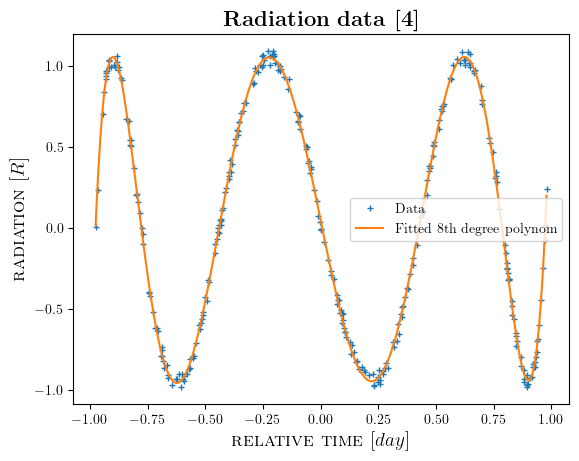

Results of measurement 4:
  a: -0.73907
  b: 64.13132
  c: 1.32837
  d: -112.24695
  e: -0.74635
  f: 56.12184
  g: 0.13598
  h: -7.00662
  j: 0.04688
The standard deviation of the measurement
  a: 0.41447
  b: 0.20547
  c: 0.74836
  d: 0.32323
  e: 0.43066
  f: 0.15070
  g: 0.08471
  h: 0.02004
  j: 0.00424


In [146]:
file_2 = "data2.npy"

def read_data2(filename):
    
    data = []
    
    raw_data = np.load(filename)
    shape = raw_data.shape
    
    for i in range(0, shape[0], 2):
        one = []
        for k, l in zip(raw_data[i], raw_data[i+1]):
            one.append([k, l])
        data.append(np.array(one))
        one = []
        
    return data


def plot(data):
    
    def f(x, a, b, c, d, e, f, g, h, j):
        return a*x**8 + b*x**7 + c*x**6 + d*x**5 + e*x**4 + f*x**3 + g*x**2 + h*x**1 + j
    
    for i, dat in enumerate(data):
        plt.plot(dat[:, 0], dat[:, 1], '+', markersize=5, label="Data")
        
        res, res_cov = np.polyfit(dat[:, 0], dat[:, 1], deg=8, cov=True)
        perr = np.sqrt(np.diag(res_cov))
        
        xdata = np.linspace(np.min(dat[:, 0]), np.max(dat[:, 0]), 300)
        fit = f(xdata, *res)
        
        plt.plot(xdata, fit, label=f"Fitted 8th degree polynom")
        
        
        plt.title(fr"\textbf{{Radiation data [{i+1}]}}", size=16)
        plt.xlabel(r"\textsc{relative time} [$day$]", size=14)
        plt.ylabel(r"\textsc{radiation} [$R$]", size=14)
    
        plt.legend()
        plt.show()
        
        print(f"Results of measurement {i+1}:")
        for m, l in zip(["a", "b", "c", "d", "e", "f", "g", "h", "j"], res):
            print(f"  {m}: {l:.5f}")
        print(f"The standard deviation of the measurement")
        for m, l in zip(["a", "b", "c", "d", "e", "f", "g", "h", "j"], perr):
            print(f"  {m}: {l:.5f}")
    
dat = read_data2(file_2)

plot(dat)

### Értelmezés
Kinek volt a legnagyobb abszolút értéke (szemmel leolvasva az eredményeket):
<br>Elsőnél az `e` paraméternek.
<br>Másodiknál az `f` paraméternek.
<br>Harmadiknál az `e` paraméternek.
<br>Negyediknél az `d` paraméternek.

---

# 3. Feladat

A `dat3.pkl` file-ban egy 200 darab kondenzátorból álló kapacitás tömb időfüggő töltöttség adatai találhatóak, melyet a tömb töltése során rögzítettek. A kapacitások sorszáma rendre 0-199. A `dat3.pkl` file egy listát tartalmaz, melynek két `array` típusú objektum az eleme. Az első egy 1000 elemből álló tömb, ami a töltési folyamat idejét tartalmazza másodpercekben mérve a töltés egy referencia időponthoz képest. 

A második egy 1000 $\times$ 200 elemből álló tömb, aminek a különböző oszlopai a különböző kondenzátorokhoz tartozó adatok, vagyis azt mutatják, hogy az adott kondenzátorban mennyi a töltöttségi szint C egységekben mérve.

- Olvasd be a file-t a `pickle` modul megfelelő függvénye segítségével!  <span style="color:red">(1p)</span>
- Illessz mind a 200 kondenzátor időfüggésére egy $$ f(t) = \frac{e^{(\tau-t)c}}{e^{(\tau-t)c}+1} $$ alakú függvényt. Az illesztéshez szükség lesz a paraméterek becslésére! (A tizedik kondenzátoron becsült paraméter értékei megfelelő becslést fognak adni a többi kondenzátor paramétereinek a meghatározására is!)  <span style="color:red">(1p)</span>
- Az illesztés során meghatározott paramétereket ($\tau$ és $c$ értékeket) és az illesztések hibáit írd ki egy `parameterek3.dat` nevű file-ba. 
A file minden oszlopa 4-4 számot tartalmazzon, az első kettő a meghatározott $\tau$ értékek, illetve azok hibája, a második két szám pedig a meghatározott $c$ értékeket és azok hibáját tartalmazza! Minden sorban, tehát 200 oszlopnak kell szerepelnie. Az oszlopokat minden sorban a `" & "` jel válassza el!   <span style="color:red">(1p)</span>
- A 137. kondenzátor mért jeleit és a rá illesztett függvényt ábrázold egy ábrán!  <span style="color:red">(1p)</span>
- Egy másik ábrán ábrázold a kondenzátorok indexe függvényében a meghatározott $\tau$ értékeket errorbar-okkal! Az errorbar nagyságát minden pontban a $\tau$ paraméter  illesztési hibájának százszorosára válaszd!  <span style="color:red">(1p)</span>


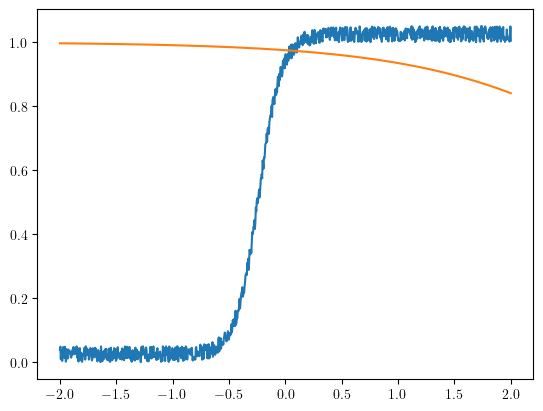

In [194]:
file_3 = "dat3.pkl"

def read_dat3(filename):
    
    with open(filename, 'rb') as file:
        tdata, condy_data = pickle.load(file)
    
    return tdata, condy_data

def f(t, tau, c):
    expo = np.exp(tau - t)*c
    return expo / (expo + 1)

def plot(tdata, cdata, i=10):
    
    plt.plot(tdata, cdata[:, i])
    
    p0 = [0.5, 23]
    res, res_cov = curve_fit(f, tdata, cdata[:, i], p0=p0)
    
    xdata = np.linspace(np.min(tdata), np.max(tdata), 1000)
    fit = f(xdata, *res)
    
    plt.plot(tdata, fit)

tdata, condy_data = read_dat3(file_3)

plot(tdata, condy_data)

---

# 4. Feladat

A `dat4.pkl` file-ban egy `dict` típusú változóban találod egy 200 rezonátorból álló hálózat rezonancia görbéit. A rezonátorok egy egyenes mentén vannak egyenletesen elosztva. A file-ban található `dict` objektum `'pozicio'` kulcsszavához tartozó `array` típusú változóban vannak a rezonátorok egyenesmenti pozíciói eltárolva cm-ben.
A file-ban található `dict` objektum `'frekvencia'` kulcsszavához tartozó `array` típusú változóban van a rezonátorok frekvenciájának mintavételezése Hz-ben.
A `'rezonancia'` kulcsszóhoz tartozó változó egy két dimenziós `array`, aminek az i. oszlopában található az i. rezonátor rezonancia görbéje. 

- Olvasd be a file-t a `pickle` modul megfelelő függvénye segítségével!  <span style="color:red">(1p)</span>
- Illessz minden rezonátor adataira egy $$ f(\nu)=\mathrm{e}^{ -\frac{(\Omega_i-\nu)^2}{\xi_i^2} } $$ alakú függvényt! **Figyelem** az illesztés során az illesztendő paraméterek becslésére is szükség lehet, ha a becslést a 100. rezonátor adataira elvégzed akkor azok hozzávetőleg jó közelítést fognak adni a többi rezonátor adatainak az illesztéséhez is!   <span style="color:red">(1p)</span>
- Az illesztés során meghatározott i-dik rezonátorhoz tartozó $\Omega_i$, $\xi_i$  paraméterek és a beolvasott `dict` változó `pozicio` kulcsszavában tárolt `array` révén rendelkezésedre áll az $\Omega_i$ és $\xi_i$ változók helyfüggése. 
    - Illessz az $\Omega_i$ értékek helyfüggésére egy $Ax^2+Bx+C$ alakú függvényt!  <span style="color:red">(0.5p)</span>
    - Illessz az $\xi_i$ paraméterek helyfüggésére egy $\Xi\sin(\omega x+\phi)+\Delta$ alakú függvényt!  <span style="color:red">(0.5p)</span>
- Készíts két ábrát, melyeken feltünteted az $\Omega_i$, $\sigma_i$ paraméterek helyfüggését és a rájuk illesztett görbéket!  <span style="color:red">(1p)</span>
- Egy Markdown cellában foglald össze az illesztett $A$, $B$, $C$, $\Xi$, $ \omega $, $ \phi $ és $\Delta$ paraméterek értékét és az illesztések hibáit!  <span style="color:red">(1p)</span>


In [ ]:
file_3 = "dat4.pkl"

def read_dat4(filename):
    
    with open(filename, 'rb') as file:
    raw_data = pickle.load(file)
    
    return raw_data